<a href="https://colab.research.google.com/github/clobos/Python_Tatiana_Ecologia_Aplicada/blob/main/notebook_prophet_vs_arima.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook-modelo: Prophet vs ARIMA para séries temporais

Este notebook apresenta um fluxo didático completo para previsão de séries temporais em Python, comparando **Prophet** e **ARIMA/SARIMAX** com foco em: preparação da série, divisão treino-teste, ajuste, diagnóstico, métricas e visualização.

## Objetivos

Ao final, você terá um roteiro reutilizável para:

- ajustar um modelo Prophet;
- ajustar um modelo ARIMA sazonal com `statsmodels`;
- comparar previsões no conjunto de teste;
- avaliar resíduos e interpretar componentes;
- adaptar o notebook para séries de produção, clima, vendas, energia ou séries ambientais.

## Requisitos

Instale, se necessário:

```python
pip install prophet statsmodels pandas numpy matplotlib seaborn scikit-learn
```

Se estiver em ambiente Conda, pode ser mais estável instalar `prophet` por `conda-forge`.

In [ ]:
!pip install prophet statsmodels pandas numpy matplotlib seaborn scikit-learn

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

from prophet import Prophet

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Carregamento dos dados

O Prophet exige um `DataFrame` com duas colunas:

- `ds`: datas;
- `y`: variável resposta.

Abaixo deixo duas opções: usar seus próprios dados ou simular uma série mensal com tendência e sazonalidade.

In [ ]:
usar_csv = False
caminho_csv = 'sua_serie.csv'  # altere se quiser usar arquivo próprio
coluna_data = 'ds'
coluna_valor = 'y'

if usar_csv:
    df = pd.read_csv(caminho_csv)
    df[coluna_data] = pd.to_datetime(df[coluna_data])
    df = df[[coluna_data, coluna_valor]].rename(columns={coluna_data: 'ds', coluna_valor: 'y'})
    df = df.sort_values('ds').reset_index(drop=True)
else:
    np.random.seed(123)
    n = 120
    datas = pd.date_range('2015-01-01', periods=n, freq='MS')
    tendencia = np.linspace(50, 130, n)
    sazonal = 12 * np.sin(2 * np.pi * np.arange(n) / 12)
    ruido = np.random.normal(0, 5, n)
    y = tendencia + sazonal + ruido
    df = pd.DataFrame({'ds': datas, 'y': y})

df.head()

,ds,y
0,2015-01-01,44.571847
1,2015-02-01,61.658996
2,2015-03-01,63.151735
3,2015-04-01,56.485333
4,2015-05-01,60.188379


In [ ]:
df.info()
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      120 non-null    datetime64[ns]
 1   y       120 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 2.0 KB


,ds,y
count,120,120.000000
mean,2019-12-16 10:48:00,90.080713
min,2015-01-01 00:00:00,39.716718
25%,2017-06-23 12:00:00,69.838699
50%,2019-12-16 12:00:00,88.442635
75%,2022-06-08 12:00:00,109.186365
max,2024-12-01 00:00:00,142.836196
std,NaN,24.640843


## 2. Inspeção inicial

Antes do ajuste, vale verificar:

- tendência global;
- sazonalidade visível;
- outliers;
- falhas/missing.

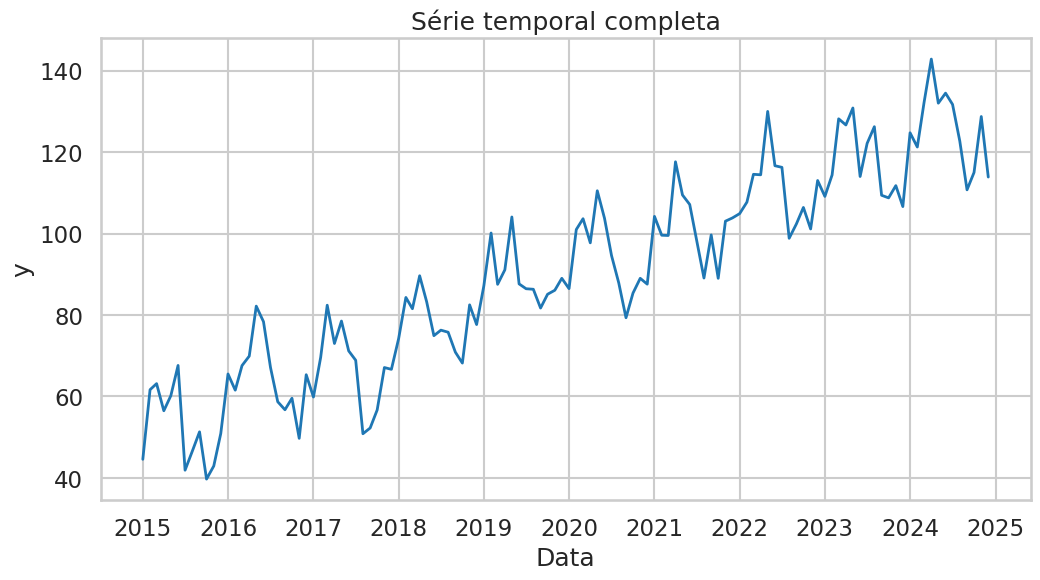

In [ ]:
fig, ax = plt.subplots()
ax.plot(df['ds'], df['y'], color='tab:blue', linewidth=2)
ax.set_title('Série temporal completa')
ax.set_xlabel('Data')
ax.set_ylabel('y')
plt.show()

In [ ]:
print('Valores ausentes em y:', df['y'].isna().sum())
print('Período inicial:', df['ds'].min())
print('Período final:', df['ds'].max())
print('Número de observações:', len(df))

Valores ausentes em y: 0
Período inicial: 2015-01-01 00:00:00
Período final: 2024-12-01 00:00:00
Número de observações: 120


## 3. Divisão treino-teste

Para avaliação honesta, separamos as últimas observações como teste.

Em séries mensais, um horizonte de 12 períodos costuma ser didático; em séries diárias, pode ser 30, 60 ou 90 dias, dependendo do problema.

In [ ]:
h = 12  # horizonte de teste
train = df.iloc[:-h].copy()
test = df.iloc[-h:].copy()

print('Treino:', train.shape)
print('Teste:', test.shape)

Treino: (108, 2)
Teste: (12, 2)


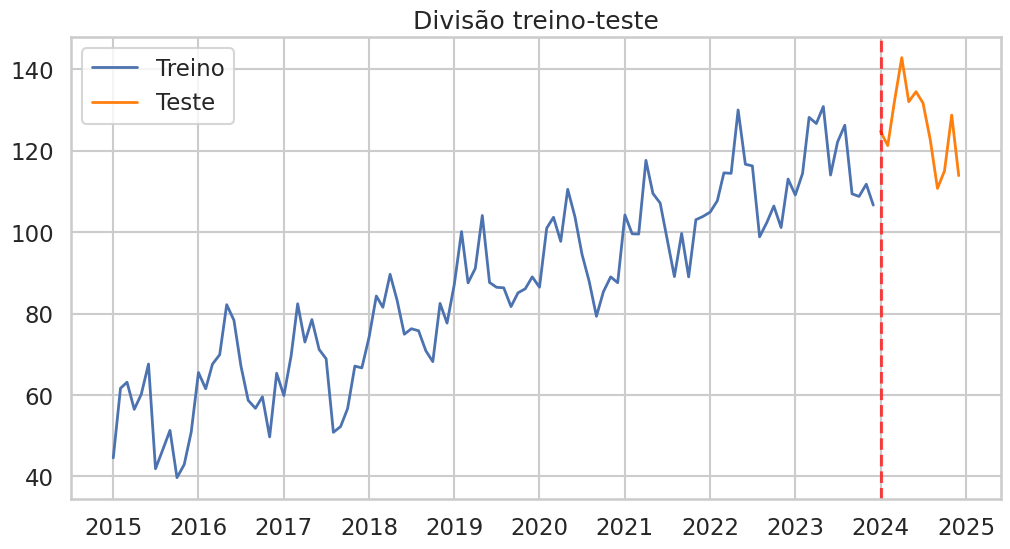

In [ ]:
fig, ax = plt.subplots()
ax.plot(train['ds'], train['y'], label='Treino', linewidth=2)
ax.plot(test['ds'], test['y'], label='Teste', linewidth=2, color='tab:orange')
ax.axvline(test['ds'].min(), color='red', linestyle='--', alpha=0.7)
ax.set_title('Divisão treino-teste')
ax.legend()
plt.show()

## 4. Modelo Prophet

O Prophet modela a série como combinação de tendência, sazonalidade e, opcionalmente, feriados/regressores.

Para séries mensais, em geral faz sentido desabilitar sazonalidade diária e semanal, mantendo a anual quando pertinente.

In [ ]:
m_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='additive'
)

m_prophet.fit(train)

In [ ]:
future = m_prophet.make_future_dataframe(periods=h, freq='MS')
forecast_prophet = m_prophet.predict(future)

pred_prophet = forecast_prophet[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(h).copy()
pred_prophet.head()

,ds,yhat,yhat_lower,yhat_upper
108,2024-01-01,121.638200,114.395761,128.638587
109,2024-02-01,131.234296,124.341155,138.359784
110,2024-03-01,131.918845,124.841442,139.166962
111,2024-04-01,132.524219,125.454001,139.278773
112,2024-05-01,139.540643,132.655184,146.600288


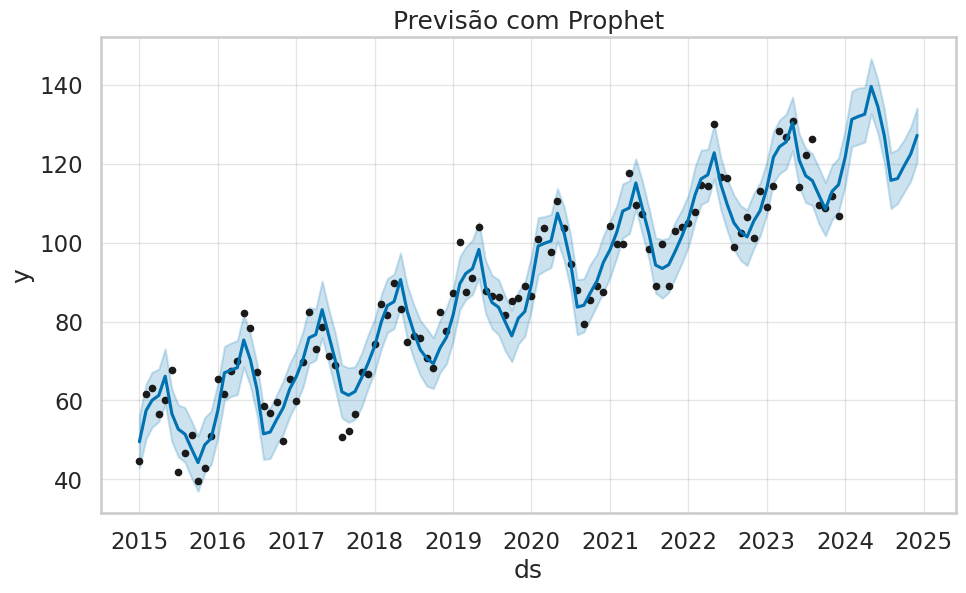

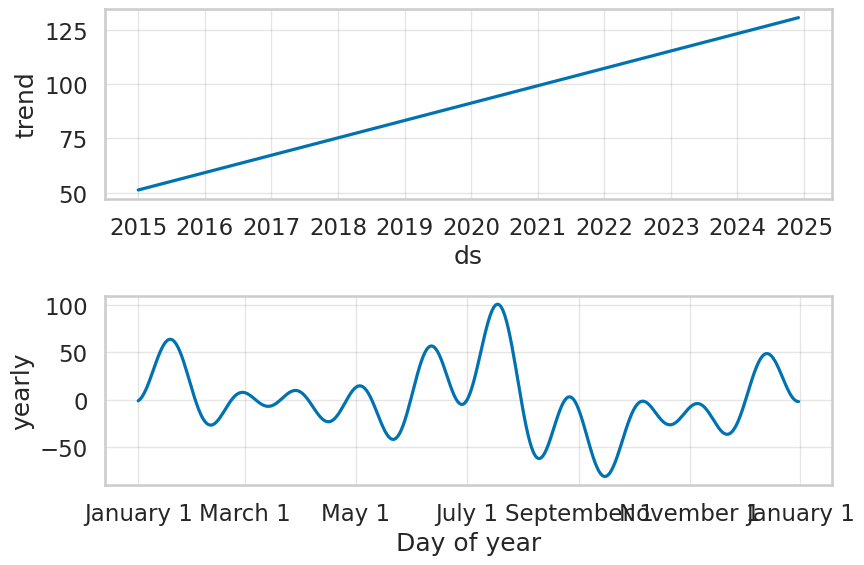

In [ ]:
fig1 = m_prophet.plot(forecast_prophet)
plt.title('Previsão com Prophet')
plt.show()

fig2 = m_prophet.plot_components(forecast_prophet)
plt.show()

## 5. Modelo ARIMA/SARIMAX

Para fins didáticos, aqui usamos um modelo SARIMAX com sazonalidade mensal.

Você pode ajustar as ordens `(p,d,q)` e `(P,D,Q,s)` conforme ACF, PACF, critérios de informação ou busca em grade.

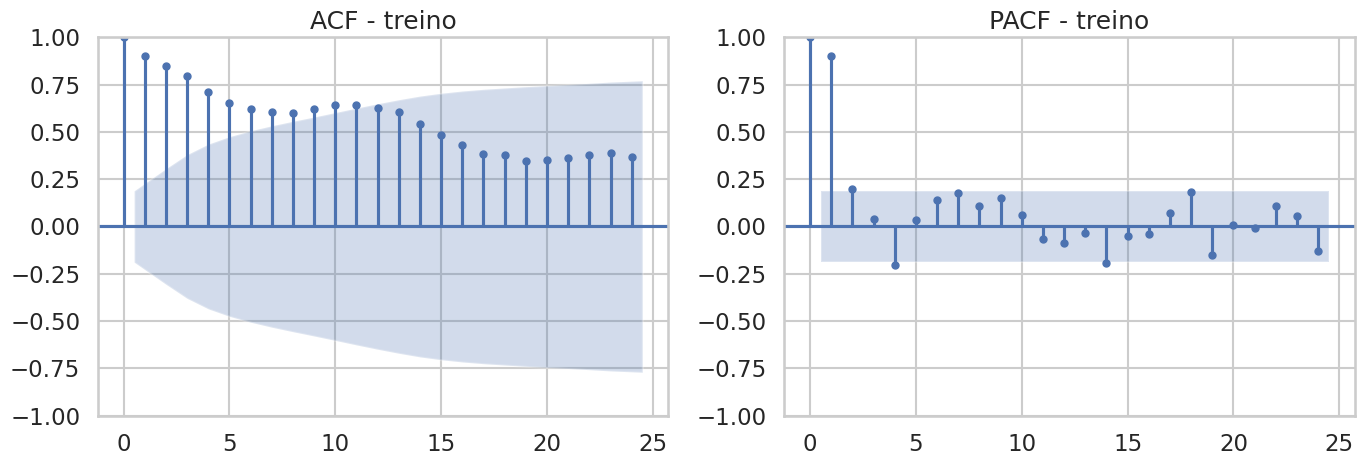

In [ ]:
serie_train = train.set_index('ds')['y']
serie_test = test.set_index('ds')['y']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_acf(serie_train, ax=axes[0], lags=24)
plot_pacf(serie_train, ax=axes[1], lags=24, method='ywm')
axes[0].set_title('ACF - treino')
axes[1].set_title('PACF - treino')
plt.tight_layout()
plt.show()

In [ ]:
ordem = (1, 1, 1)
ordem_sazonal = (1, 1, 1, 12)

m_arima = SARIMAX(
    serie_train,
    order=ordem,
    seasonal_order=ordem_sazonal,
    enforce_stationarity=False,
    enforce_invertibility=False
)

res_arima = m_arima.fit(disp=False)
res_arima.summary()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                  108
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -267.910
Date:                            Thu, 16 Apr 2026   AIC                            545.820
Time:                                    13:54:43   BIC                            557.792
Sample:                                01-01-2015   HQIC                           550.623
                                     - 12-01-2023                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0318      0.177     -0.179      0.858      -0.380       0.316
ma.L1         -0.8701      0.085    -10.275      0.000      -1.036      -0.704
ar.S.L12      -0.1549      0.127     -1.216      0.224      -0.404       0.095
ma.S.L12      -1.0000   1.23e+04  -8.13e-05      1.000   -2.41e+04    2.41e+04
sigma2        32.3667   3.98e+05   8.13e-05      1.000    -7.8e+05     7.8e+05
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 2.70
Prob(Q):                              0.98   Prob(JB):                         0.26
Heteroskedasticity (H):               0.76   Skew:                             0.39
Prob(H) (two-sided):                  0.47   Kurtosis:                         2.57
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [ ]:
pred_arima_obj = res_arima.get_forecast(steps=h)
pred_arima = pred_arima_obj.predicted_mean
ic_arima = pred_arima_obj.conf_int()

pred_arima_df = pd.DataFrame({
    'ds': serie_test.index,
    'yhat': pred_arima.values,
    'yhat_lower': ic_arima.iloc[:, 0].values,
    'yhat_upper': ic_arima.iloc[:, 1].values
})

pred_arima_df.head()

,ds,yhat,yhat_lower,yhat_upper
0,2024-01-01,122.090020,110.227487,133.952553
1,2024-02-01,127.946264,116.027862,139.864667
2,2024-03-01,129.435692,117.423509,141.447876
3,2024-04-01,131.748448,119.644375,143.852521
4,2024-05-01,138.124185,125.928873,150.319497


## 6. Comparação de previsões

Agora comparamos Prophet e ARIMA no mesmo horizonte de teste.

In [ ]:
comparacao = test[['ds', 'y']].copy()
comparacao = comparacao.merge(pred_prophet[['ds', 'yhat']], on='ds', how='left')
comparacao = comparacao.rename(columns={'yhat': 'prophet'})
comparacao = comparacao.merge(pred_arima_df[['ds', 'yhat']], on='ds', how='left')
comparacao = comparacao.rename(columns={'yhat': 'arima'})
comparacao.head()

,ds,y,prophet,arima
0,2024-01-01,124.735775,121.638200,122.090020
1,2024-02-01,121.250262,131.234296,127.946264
2,2024-03-01,132.203487,131.918845,129.435692
3,2024-04-01,142.836196,132.524219,131.748448
4,2024-05-01,132.010338,139.540643,138.124185


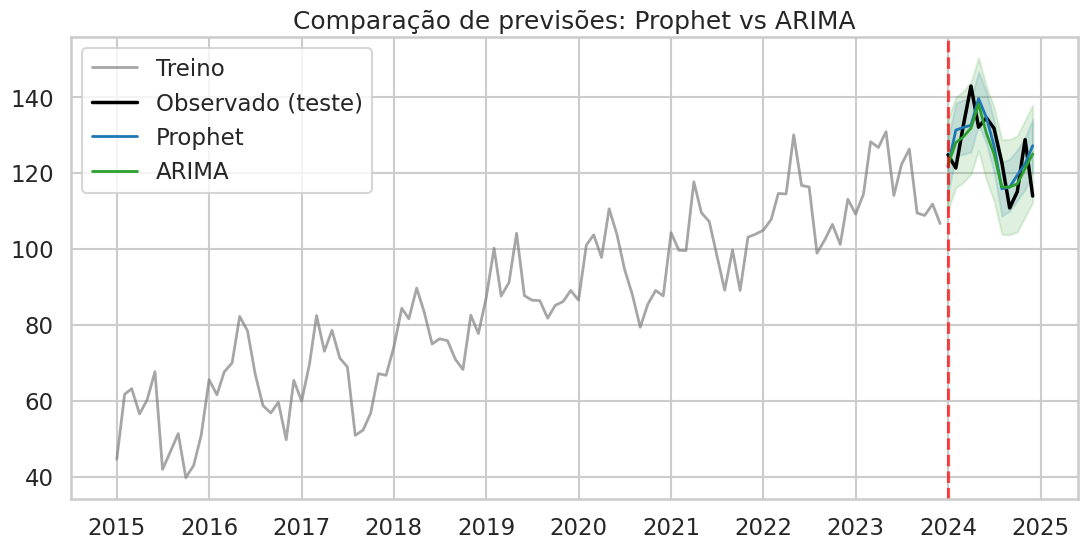

In [ ]:
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(train['ds'], train['y'], label='Treino', linewidth=2, color='gray', alpha=0.7)
ax.plot(test['ds'], test['y'], label='Observado (teste)', linewidth=2.5, color='black')
ax.plot(pred_prophet['ds'], pred_prophet['yhat'], label='Prophet', linewidth=2, color='tab:blue')
ax.fill_between(pred_prophet['ds'], pred_prophet['yhat_lower'], pred_prophet['yhat_upper'], color='tab:blue', alpha=0.15)
ax.plot(pred_arima_df['ds'], pred_arima_df['yhat'], label='ARIMA', linewidth=2, color='tab:green')
ax.fill_between(pred_arima_df['ds'], pred_arima_df['yhat_lower'], pred_arima_df['yhat_upper'], color='tab:green', alpha=0.15)
ax.axvline(test['ds'].min(), color='red', linestyle='--', alpha=0.7)
ax.set_title('Comparação de previsões: Prophet vs ARIMA')
ax.legend()
plt.show()

## 7. Métricas de desempenho

Usamos MAE, RMSE e MAPE.

Se houver valores muito próximos de zero, interprete o MAPE com cautela.

In [ ]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

metricas = pd.DataFrame({
    'modelo': ['Prophet', 'ARIMA'],
    'MAE': [
        mean_absolute_error(comparacao['y'], comparacao['prophet']),
        mean_absolute_error(comparacao['y'], comparacao['arima'])
    ],
    'RMSE': [
        rmse(comparacao['y'], comparacao['prophet']),
        rmse(comparacao['y'], comparacao['arima'])
    ],
    'MAPE': [
        mean_absolute_percentage_error(comparacao['y'], comparacao['prophet']),
        mean_absolute_percentage_error(comparacao['y'], comparacao['arima'])
    ]
})

metricas.sort_values('RMSE')

,modelo,MAE,RMSE,MAPE
1,ARIMA,6.066715,6.695563,0.048263
0,Prophet,6.014929,7.109817,0.048593


In [ ]:
metricas_formatadas = metricas.copy()
metricas_formatadas['MAPE (%)'] = 100 * metricas_formatadas['MAPE']
metricas_formatadas = metricas_formatadas.drop(columns='MAPE')
metricas_formatadas

,modelo,MAE,RMSE,MAPE (%)
0,Prophet,6.014929,7.109817,4.859338
1,ARIMA,6.066715,6.695563,4.826327


## 8. Diagnóstico de resíduos

No ARIMA, é importante verificar se os resíduos se aproximam de ruído branco.

No Prophet, podemos ao menos inspecionar resíduos simples no treino, embora a estrutura de diagnóstico seja menos clássica que em ARIMA.

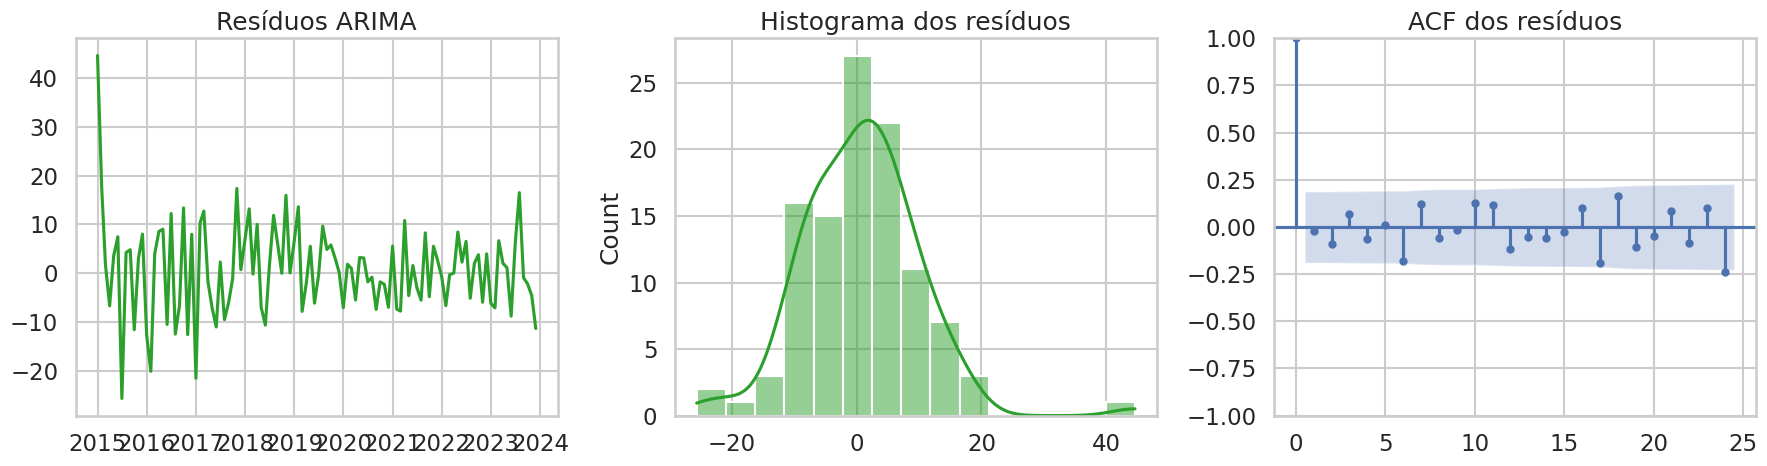

In [ ]:
residuos_arima = res_arima.resid

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(residuos_arima, color='tab:green')
axes[0].set_title('Resíduos ARIMA')
sns.histplot(residuos_arima, kde=True, ax=axes[1], color='tab:green')
axes[1].set_title('Histograma dos resíduos')
plot_acf(residuos_arima.dropna(), ax=axes[2], lags=24)
axes[2].set_title('ACF dos resíduos')
plt.tight_layout()
plt.show()

In [ ]:
ljung_box = acorr_ljungbox(residuos_arima.dropna(), lags=[12], return_df=True)
ljung_box

,lb_stat,lb_pvalue
12,13.091868,0.362399


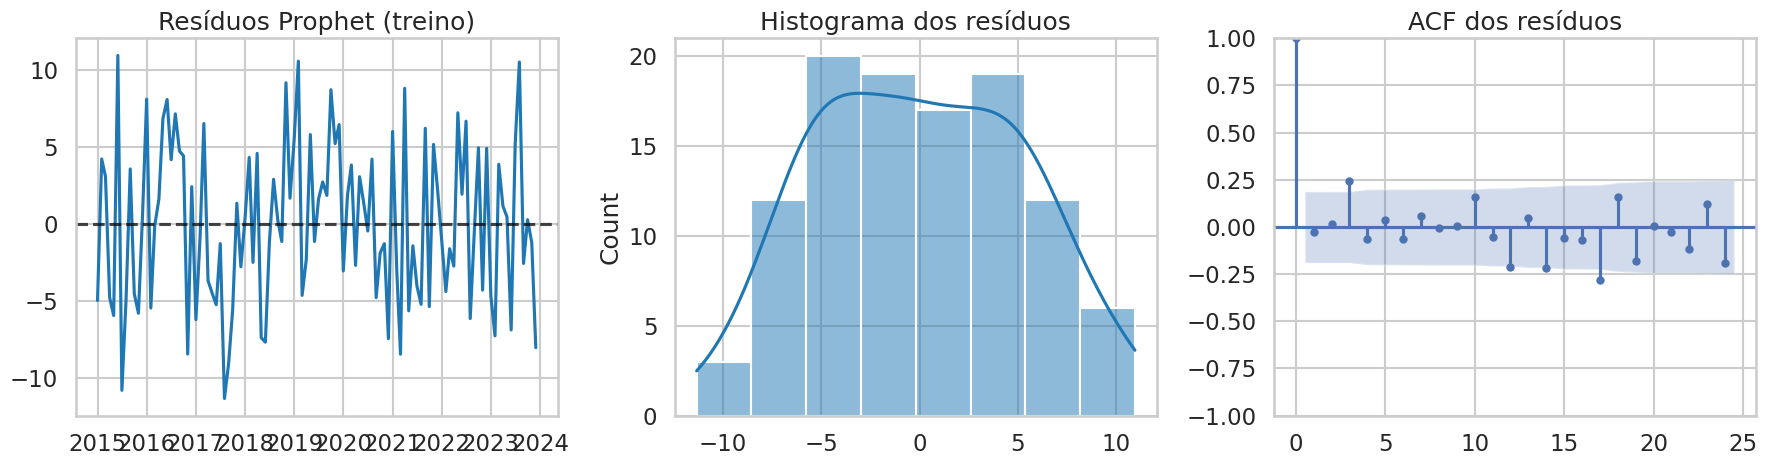

In [ ]:
forecast_train_prophet = m_prophet.predict(train[['ds']])
residuos_prophet = train['y'].values - forecast_train_prophet['yhat'].values

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(train['ds'], residuos_prophet, color='tab:blue')
axes[0].axhline(0, color='black', linestyle='--', alpha=0.7)
axes[0].set_title('Resíduos Prophet (treino)')
sns.histplot(residuos_prophet, kde=True, ax=axes[1], color='tab:blue')
axes[1].set_title('Histograma dos resíduos')
plot_acf(pd.Series(residuos_prophet).dropna(), ax=axes[2], lags=24)
axes[2].set_title('ACF dos resíduos')
plt.tight_layout()
plt.show()

## 9. Comentários interpretativos

Pontos para discutir com alunos ou em relatório:

- **Prophet** tende a ser muito conveniente para séries com sazonalidades claras, feriados e necessidade de comunicação visual rápida.
- **ARIMA/SARIMAX** tende a ser mais clássico e transparente para modelagem da dependência temporal e diagnóstico residual.
- O melhor modelo depende do horizonte, da frequência da série, da estabilidade dos padrões e do objetivo analítico.
- Em aplicações reais, compare também com modelos ingênuos (`naive`, sazonal naive) para evitar benchmark fraco.

## 10. Extensões úteis

Você pode expandir este notebook com:

- regressoras externas em Prophet e SARIMAX;
- feriados específicos do Brasil;
- rolling-origin evaluation / time series cross-validation;
- busca em grade para ordens ARIMA;
- comparação com ETS, TBATS, XGBoost ou LSTM;
- exportação automática de tabelas e gráficos para relatório.

## 11. Template para adaptar aos seus dados

Checklist rápido:

1. Substituir a etapa de simulação pelo seu CSV.
2. Garantir colunas `ds` e `y`.
3. Ajustar a frequência (`D`, `W`, `MS`, etc.).
4. Definir horizonte de teste compatível com o problema.
5. Revisar sazonalidades do Prophet.
6. Revisar ordens do ARIMA com base em ACF/PACF e critérios de informação.
7. Interpretar métricas e resíduos, não apenas escolher o menor erro.